In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('../../../data/raw/lecture/tmdb_5000_movies.csv')
len(df)

4803

In [9]:
df = df[(df != 0).all(axis=1)]
len(df)

3227

In [3]:
df['release_date']

0       2009-12-10
1       2007-05-19
2       2015-10-26
3       2012-07-16
4       2012-03-07
           ...    
4798    1992-09-04
4799    2011-12-26
4800    2013-10-13
4801    2012-05-03
4802    2005-08-05
Name: release_date, Length: 4803, dtype: str

In [10]:
df['year'] = df['release_date'].apply(lambda x: x.split('-')[0])
df['month'] = df['release_date'].apply(lambda x: x.split('-')[1])
df.head(3)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,year,month
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,2009,12
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,2007,05
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,2015,10


/tmp/ipykernel_1512/348646589.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['vote_average'])


<Axes: xlabel='vote_average', ylabel='Density'>

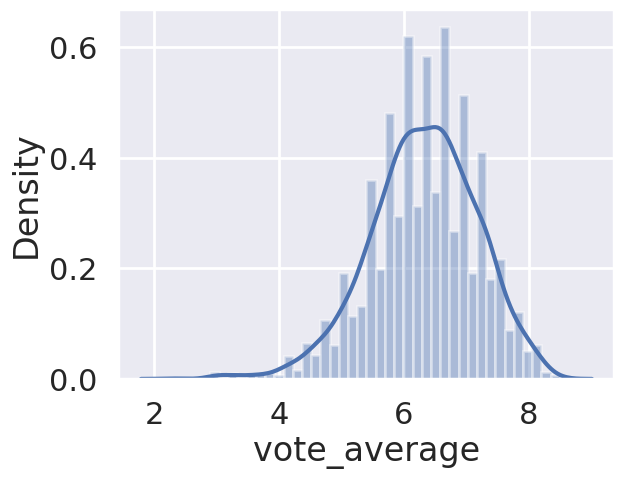

In [17]:
sns.set_context('poster')
sns.distplot(df['vote_average'])

/tmp/ipykernel_1512/2373636471.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['vote_average'])


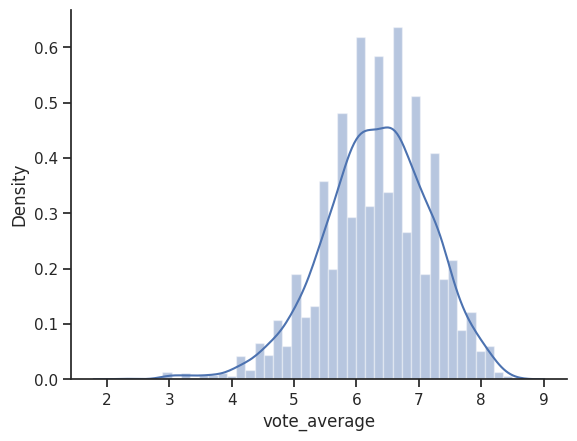

In [22]:
sns.set_context('notebook')
sns.set_style('ticks')
sns.distplot(df['vote_average'])
sns.despine()

In [25]:
df['decade'] = df['year'].apply(lambda x: x[:-1] + '0s')
df['decade']

0       2000s
1       2000s
2       2010s
3       2010s
4       2010s
        ...  
4773    1990s
4788    1970s
4792    1990s
4796    2000s
4798    1990s
Name: decade, Length: 3227, dtype: str

In [28]:
df['evaluation'] = df['vote_average'].apply(lambda x: 'low' if x < df['vote_average'].median(numeric_only=True) else 'high')
df['evaluation']

0       high
1       high
2       high
3       high
4        low
        ... 
4773    high
4788     low
4792    high
4796    high
4798    high
Name: evaluation, Length: 3227, dtype: str

In [31]:
df.head(3)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,spoken_languages,status,tagline,title,vote_average,vote_count,year,month,decade,evaluation
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,2009,12,2000s,high
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,2007,05,2000s,high
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,2015,10,2010s,high


In [26]:
df['popularity']

0       150.437577
1       139.082615
2       107.376788
3       112.312950
4        43.926995
           ...    
4773     19.748658
4788      4.553644
4792      0.212443
4796     23.307949
4798     14.269792
Name: popularity, Length: 3227, dtype: float64

<Axes: xlabel='decade', ylabel='popularity'>

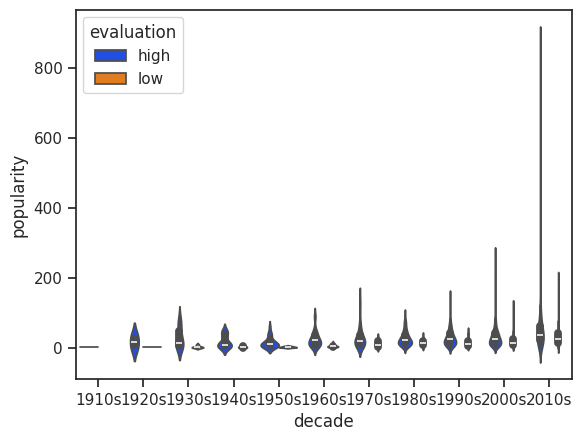

In [43]:
sns.set_context('notebook')
sns.set_style('ticks')
sns.set_palette('bright')
sns.violinplot(data=df.sort_values('decade'), x='decade', y='popularity', hue='evaluation')

/tmp/ipykernel_1512/3002119498.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df.sort_values('decade'), x='decade', y='popularity', palette='dark')


<Axes: xlabel='decade', ylabel='popularity'>

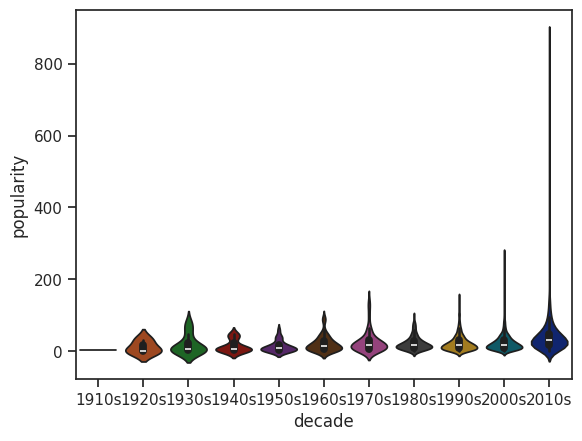

In [45]:
sns.set_context('notebook')
sns.set_style('ticks')
# sns.set_palette('bright')
sns.violinplot(data=df.sort_values('decade'), x='decade', y='popularity', palette='dark')

/tmp/ipykernel_1512/3002124763.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['vote_average'])


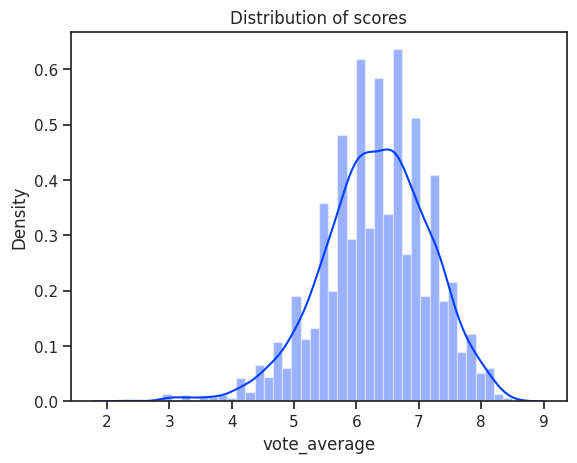

In [48]:
sns.distplot(df['vote_average'])
plt.title('Distribution of scores')
plt.savefig('saved_searborn.png')

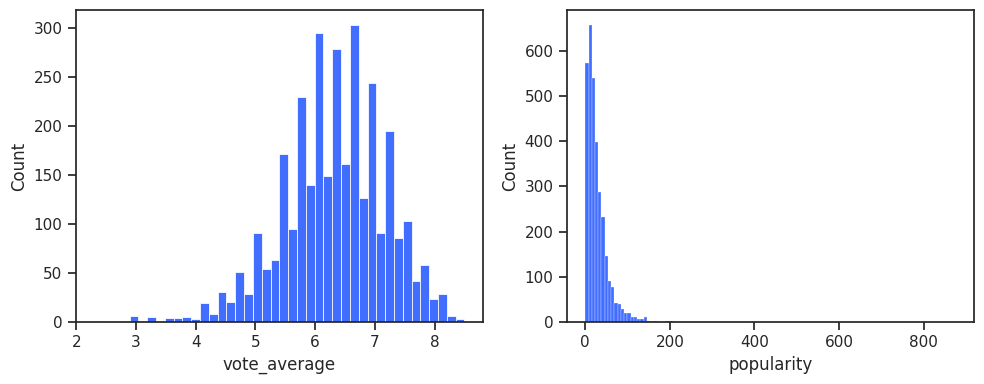

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(ax=axes[0], data=df['vote_average'])
sns.histplot(ax=axes[1], data=df['popularity'])
plt.tight_layout()
plt.show()

<Axes: >